In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
# Example: Using the built-in Iris dataset (use own data here)
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data # Features
y = iris.target # Target variable (optional, for visualization later)
features = iris.feature_names

# Standardize the features (important first step for PCA!)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)


In [8]:
features?

Type:        list
String form: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Length:      4
Docstring:  
Built-in mutable sequence.

If no argument is given, the constructor creates a new empty list.
The argument must be an iterable if specified.

In [3]:
# Retain 95% of the variance
pca = PCA(n_components=0.95)

# Fit and transform the standardized data
X_pca = pca.fit_transform(X_std)

print(f"Original shape: {X.shape}")
print(f"Transformed shape: {X_pca.shape}")
print(f"Number of components chosen: {pca.n_components_}")


Original shape: (150, 4)
Transformed shape: (150, 2)
Number of components chosen: 2


Explained variance per component: [0.72962445 0.22850762]
Cumulative explained variance: [0.72962445 0.95813207]


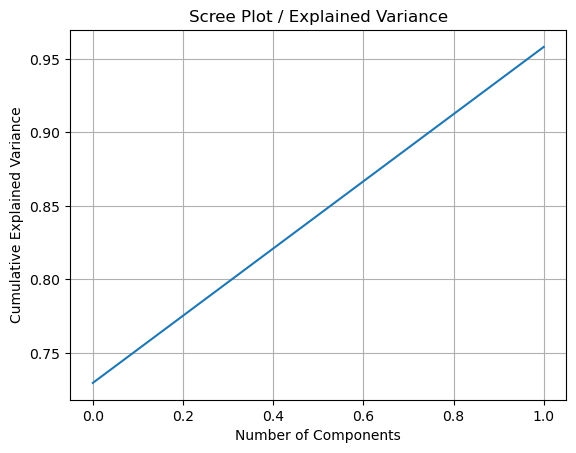

In [4]:
# View the explained variance ratio for each 
# component
print(f"Explained variance per component: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance: {np.cumsum(pca.explained_variance_ratio_)}")

# Plot the cumulative explained variance to help 
# choose the number of components
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot / Explained Variance')
plt.grid()
plt.show()


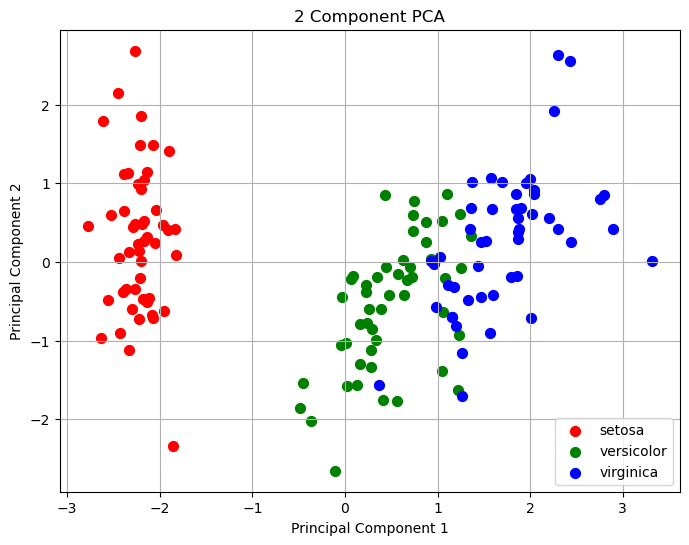

In [5]:
# Assuming you set n_components=2 for 
# visualization purposes
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_std)

plt.figure(figsize=(8, 6))
for target, color in zip(np.unique(y), ['r', 'g', 'b']):
    indices_to_keep = (y == target)
    plt.scatter(X_pca_2d[indices_to_keep, 0], 
                X_pca_2d[indices_to_keep, 1], 
                c=color, 
                s=50,
                label=iris.target_names[target])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2 Component PCA')
plt.legend()
plt.grid()
plt.show()


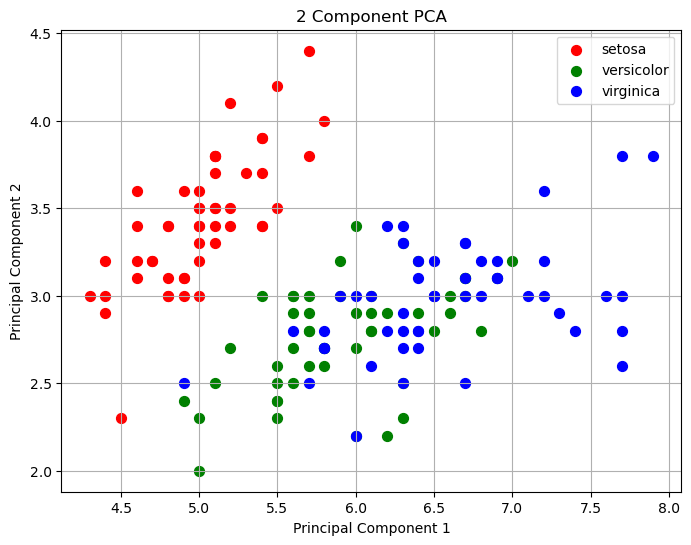

In [6]:
# Assuming you set n_components=2 for 
# visualization purposes
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_std)

plt.figure(figsize=(8, 6))
for target, color in zip(np.unique(y), ['r', 'g', 'b']):
    indices_to_keep = (y == target)
    plt.scatter(X[indices_to_keep, 0], 
                X[indices_to_keep, 1], 
                c=color, 
                s=50,
                label=iris.target_names[target])
plt.xlabel(features[0])
plt.ylabel()
plt.title(Plot using two first fiatures)
plt.legend()
plt.grid()
plt.show()


### Question: Why the former plot does not look like rotated latter plot?